# NLP and Sequence Modeling Mini Project

In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [124]:
df = pd.read_csv("customer_support_text_classification.csv")

In [125]:
print(df.head())

  ticket_id channel                                   customer_message  \
0  TKT00001    chat  I need information about the payment process. ...   
1  TKT00002   phone      I need information about the payment process.   
2  TKT00003   email  The refund process was fast and convenient. I ...   
3  TKT00004  social  My refund is still pending and this experience...   
4  TKT00005    chat   Please tell me how to update my account details.   

  sentiment_label  word_count  urgent_flag  
0         neutral          18            1  
1         neutral           7            0  
2        positive          12            0  
3        negative          15            1  
4         neutral           9            0  


In [126]:
print(df.columns)

Index(['ticket_id', 'channel', 'customer_message', 'sentiment_label',
       'word_count', 'urgent_flag'],
      dtype='str')


# Task 1: Dataset Understanding

In [127]:
print("Total Records:", len(df))

Total Records: 1500


In [128]:
print(df['sentiment_label'].unique())

<StringArray>
['neutral', 'positive', 'negative']
Length: 3, dtype: str


In [129]:
print(df['customer_message'].sample(5))

125     Can you confirm whether my ticket has been ass...
169           The refund process was fast and convenient.
1132        I need information about the payment process.
367     Can you share the status of my order request? ...
806     The app crashes whenever I try to use profile ...
Name: customer_message, dtype: str


In [130]:
print(df['customer_message'].sample(5))

263     Can you confirm whether my ticket has been ass...
746     I am very unhappy because my mobile app has no...
1367    The dashboard is working well and I am happy w...
88      I would like to know more about the available ...
613     I am very unhappy because my insurance policy ...
Name: customer_message, dtype: str


In [131]:
df['text_length'] = df['customer_message'].apply(len)

print("Average Text Length:", df['text_length'].mean())

Average Text Length: 72.75666666666666


In [132]:
print(df['sentiment_label'].value_counts())

sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64


# Task 2: Text Preprocessing

Text preprocessing helps clean and standardize text before model training.
This includes lowercasing, removing special characters, tokenization, and stopword removal.

In [133]:
%pip install nltk

Note: you may need to restart the kernel to use updated packages.


In [134]:
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [135]:
import nltk

nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\aksch\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [136]:
stop_words = set(stopwords.words('english'))

In [137]:
def preprocess(text):

    # lowercase
    text = text.lower()

    # remove special characters
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)

    # tokenization
    tokens = word_tokenize(text)

    # remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    return " ".join(tokens)

In [138]:
df['clean_text'] = df['customer_message'].apply(preprocess)

In [139]:
print(df[['customer_message', 'clean_text']].head())

                                    customer_message  \
0  I need information about the payment process. ...   
1      I need information about the payment process.   
2  The refund process was fast and convenient. I ...   
3  My refund is still pending and this experience...   
4   Please tell me how to update my account details.   

                                          clean_text  
0  need information payment process ticket number...  
1                   need information payment process  
2  refund process fast convenient appreciate quic...  
3  refund still pending experience frustrating ti...  
4                 please tell update account details  


# Task 3: Text Vectorization

Machine learning models cannot understand raw text directly.
Text must be converted into numerical vectors before training.
TF-IDF converts important words into weighted numerical features.

In [140]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['clean_text'])

y = df['sentiment_label']

In [141]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [142]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [143]:
y_pred = model.predict(X_test)

In [144]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       109
     neutral       1.00      1.00      1.00       104
    positive       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



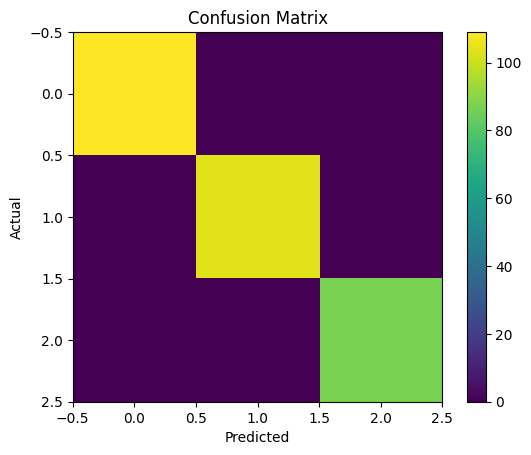

In [145]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.colorbar()

plt.show()

# Task 5: Sequence Model (LSTM)

The LSTM model processes text sequentially using embeddings and memory cells.
It helps preserve long-term dependencies in text sequences.

In [146]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

In [147]:
tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(df['clean_text'])

sequences = tokenizer.texts_to_sequences(df['clean_text'])

In [148]:
X_seq = pad_sequences(sequences, maxlen=100)

In [149]:
print(df['sentiment_label'].unique())

<StringArray>
['neutral', 'positive', 'negative']
Length: 3, dtype: str


In [150]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(df['sentiment_label'])

In [151]:
model = Sequential([
    Embedding(input_dim=5000, output_dim=128, input_length=100),

    LSTM(64),

    Dense(1, activation='sigmoid')
])

c:\Users\aksch\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [152]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
model.fit(
    X_seq,
    y_encoded,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.3558 - loss: -0.0637 - val_accuracy: 0.3833 - val_loss: -0.9957
Epoch 2/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.5475 - loss: -2.4480 - val_accuracy: 0.6567 - val_loss: -4.1265
Epoch 3/5
10/38 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6801 - loss: -4.0005

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 100, 128)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,068,421 (7.89 MB)

 Trainable params: 689,473 (2.63 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,378,948 (5.26 MB)

# Task 6: Attention and Transformer Reflection

## Why RNNs Struggle with Long-Term Dependencies

RNNs process sequences one word at a time, but they struggle to remember earlier information in long sentences due to vanishing gradients.

## How LSTMs Help

LSTMs use memory cells and gates to preserve important information for longer durations, improving sequence learning performance.

## What Attention Solves

Attention mechanisms allow models to focus directly on important words in a sequence instead of relying only on previous hidden states.

## Why Transformers are Important

Transformers use self-attention and parallel processing, making them highly effective for NLP tasks and Generative AI systems like GPT and BERT.

In [ ]:
with open("results/sample_predictions.txt", "w") as f:

    for i in range(10):
        f.write(f"Actual: {y_test.iloc[i]}\n")
        f.write(f"Predicted: {y_pred[i]}\n\n")

In [ ]:
results = pd.DataFrame({
    "Metric": ["Accuracy"],
    "Value": [accuracy_score(y_test, y_pred)]
})

results.to_csv("results/model_evaluation.csv", index=False)